# 04 — Sleep Staging & Cardiac Dynamics

**Goal**: Understand how sleep architecture shapes heart rate and autonomic regulation.

Sleep is not uniform — it cycles through stages with distinct physiological signatures:
- **Wake**: high HR, high sympathetic tone
- **N1/N2**: transitional, HR decreasing
- **N3 (Deep/SWS)**: lowest HR, highest vagal tone, high RMSSD
- **REM**: HR increases again, vivid dreaming, muscle atonia

---

## Pipeline
1. Simulate a full night hypnogram (sleep stage sequence)
2. Model HR as a function of sleep stage
3. Compute windowed RMSSD (HRV proxy)
4. Visualize HR distribution per stage
5. Explore multi-day patterns from MMASH

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import signal
import warnings
warnings.filterwarnings('ignore')


In [2]:

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'axes.grid':        True,
})

BLUE   = '#58a6ff'
GREEN  = '#3fb950'
RED    = '#f78166'
PURPLE = '#d2a8ff'
ORANGE = '#ffa657'
MUTED  = '#8b949e'

np.random.seed(42)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Simulate a Full Night Hypnogram

A typical night cycles through ~4-5 NREM/REM cycles, each ~90 minutes.
Deep sleep (N3) dominates early in the night; REM lengthens toward morning.

Sleep stage durations (minutes):
  Wake        : 9 min
  N1          : 54 min
  N2          : 168 min
  N3 (Deep)   : 207 min
  REM         : 42 min


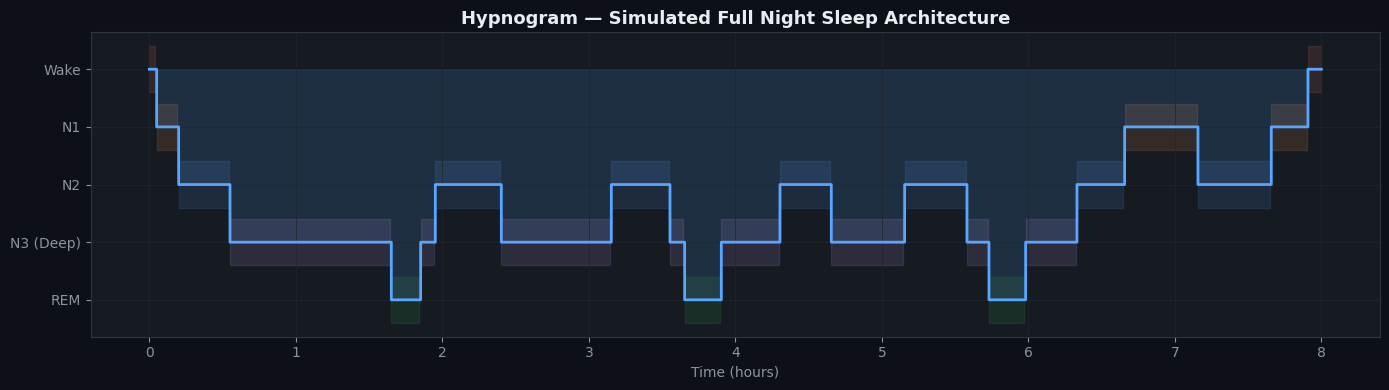

In [3]:
# Sleep stage encoding: 0=Wake, 1=N1, 2=N2, 3=N3, 4=REM
STAGE_NAMES  = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3 (Deep)', 4: 'REM'}
STAGE_COLORS = {0: RED, 1: ORANGE, 2: BLUE, 3: PURPLE, 4: GREEN}

# Hypnogram: (time_hours, stage) breakpoints
hyp_times  = [0.0, 0.1, 0.3, 0.8, 1.5, 1.8, 2.0, 2.8, 3.5,
               3.7, 4.5, 4.8, 5.5, 5.8, 6.5, 6.8, 7.5, 7.8, 8.0]
hyp_stages = [0,   1,   2,   3,   3,   4,   2,   3,   2,
               4,   2,   3,   2,   4,   2,   1,   2,   1,   0]

# High-resolution time axis (30s epochs = standard PSG)
EPOCH_S   = 30          # epoch duration in seconds
N_EPOCHS  = int(8 * 3600 / EPOCH_S)  # 8 hours
epoch_t   = np.linspace(0, 8, N_EPOCHS)  # in hours
stage_arr = np.round(np.interp(epoch_t, hyp_times, hyp_stages)).astype(int)

# Stage duration summary
stage_counts = {STAGE_NAMES[s]: np.sum(stage_arr == s) * EPOCH_S / 60
                for s in range(5)}
print('Sleep stage durations (minutes):')
for name, mins in stage_counts.items():
    print(f'  {name:<12}: {mins:.0f} min')

# Plot hypnogram
fig, ax = plt.subplots(figsize=(14, 4))
ax.step(epoch_t, stage_arr, color=BLUE, lw=2, where='post')
ax.fill_between(epoch_t, stage_arr, step='post', alpha=0.15, color=BLUE)

# Color bands per stage
for s in range(5):
    mask = stage_arr == s
    if mask.any():
        ax.fill_between(epoch_t, s - 0.4, s + 0.4,
                        where=mask, alpha=0.12, color=STAGE_COLORS[s])

ax.set_yticks(range(5))
ax.set_yticklabels([STAGE_NAMES[i] for i in range(5)])
ax.invert_yaxis()
ax.set_xlabel('Time (hours)')
ax.set_title('Hypnogram — Simulated Full Night Sleep Architecture', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/04_hypnogram.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 2. Model Heart Rate During Sleep

HR is inversely related to sleep depth:
- **N3**: HR ~45–55 bpm (peak parasympathetic/vagal activity)
- **REM**: HR rises to ~60–70 bpm (autonomic instability)
- **Wake**: HR ~65–75 bpm

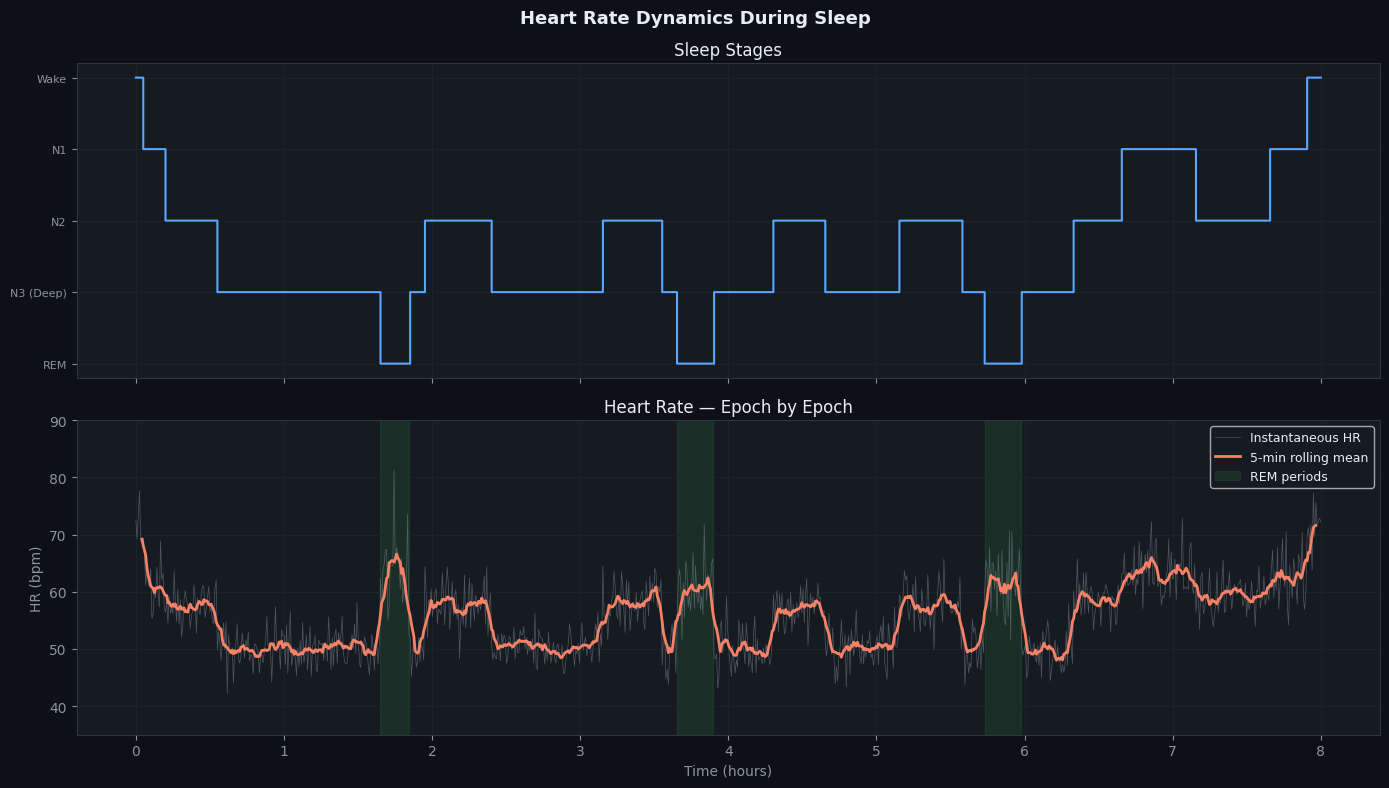

In [4]:
# HR per stage (mean ± noise)
STAGE_HR_MEAN = {0: 70, 1: 63, 2: 58, 3: 50, 4: 62}
STAGE_HR_STD  = {0: 5,  1: 4,  2: 3,  3: 3,  4: 5}

hr_night = np.array([
    np.random.normal(STAGE_HR_MEAN[s], STAGE_HR_STD[s])
    for s in stage_arr
])
hr_night = np.clip(hr_night, 38, 90)

# Rolling mean (5-min window)
window_epochs = int(5 * 60 / EPOCH_S)  # 5 minutes in epochs
hr_smooth = pd.Series(hr_night).rolling(window_epochs, center=True).mean().values

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Heart Rate Dynamics During Sleep', fontsize=13, fontweight='bold')

# Hypnogram (mini)
axes[0].step(epoch_t, stage_arr, color=BLUE, lw=1.5, where='post')
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([STAGE_NAMES[i] for i in range(5)], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title('Sleep Stages')

# HR
axes[1].plot(epoch_t, hr_night,  color=MUTED,  lw=0.5, alpha=0.5, label='Instantaneous HR')
axes[1].plot(epoch_t, hr_smooth, color=RED,    lw=2.0,             label='5-min rolling mean')

# Shade REM periods
rem_mask = stage_arr == 4
axes[1].fill_between(epoch_t, 35, 95, where=rem_mask,
                     alpha=0.12, color=GREEN, label='REM periods')
axes[1].set_ylim(35, 90)
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('HR (bpm)')
axes[1].set_title('Heart Rate — Epoch by Epoch')
axes[1].legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/04_hr_overnight.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 3. RMSSD — HRV as Vagal Tone Proxy

RMSSD (root mean square of successive RR differences) reflects
parasympathetic (vagal) nervous system activity.
High RMSSD = high vagal tone = good recovery.

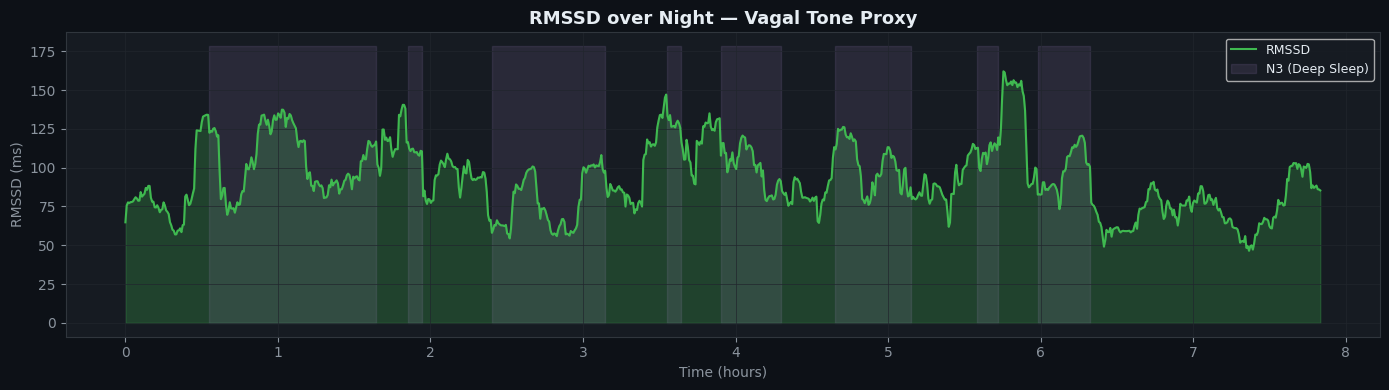

Mean RMSSD overall : 93.0 ms
Mean RMSSD N3      : 98.2 ms


In [5]:
def compute_rmssd(rr_ms, window=10):
    """Compute RMSSD over a sliding window of RR intervals."""
    rmssd_vals = []
    for i in range(len(rr_ms) - window):
        diffs = np.diff(rr_ms[i:i+window])
        rmssd_vals.append(np.sqrt(np.mean(diffs**2)))
    return np.array(rmssd_vals)

# Simulate RR intervals from HR (RR = 60000/HR in ms)
rr_ms = 60000 / hr_night
# Add realistic HRV: more variability in deep sleep
hrv_noise = np.array([np.random.normal(0, 5 + 10*(s==3) + 5*(s==4))
                       for s in stage_arr])
rr_ms = rr_ms + hrv_noise

rmssd = compute_rmssd(rr_ms, window=20)
rmssd_t = epoch_t[:len(rmssd)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(rmssd_t, rmssd, alpha=0.25, color=GREEN)
ax.plot(rmssd_t, rmssd, color=GREEN, lw=1.5, label='RMSSD')

# Mark deep sleep periods
deep_mask = stage_arr[:len(rmssd)] == 3
ax.fill_between(rmssd_t, 0, np.max(rmssd)*1.1,
                where=deep_mask, alpha=0.1, color=PURPLE, label='N3 (Deep Sleep)')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('RMSSD (ms)')
ax.set_title('RMSSD over Night — Vagal Tone Proxy', fontsize=13, fontweight='bold')
ax.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/04_rmssd.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'Mean RMSSD overall : {rmssd.mean():.1f} ms')
print(f'Mean RMSSD N3      : {rmssd[deep_mask[:len(rmssd)]].mean():.1f} ms')

## 4. HR Distribution by Sleep Stage

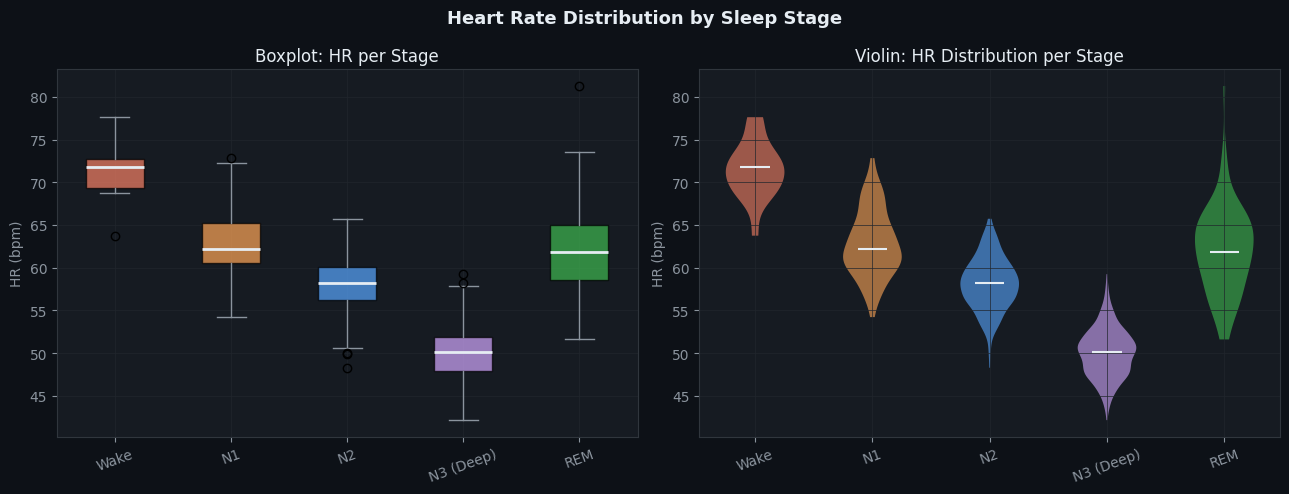

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Heart Rate Distribution by Sleep Stage', fontsize=13, fontweight='bold')

# Boxplot
stage_hr_data = [hr_night[stage_arr == s] for s in range(5)]
stage_labels  = [STAGE_NAMES[s] for s in range(5)]

bp = axes[0].boxplot(stage_hr_data, labels=stage_labels,
                     patch_artist=True,
                     medianprops=dict(color='#e6edf3', lw=2))

for patch, s in zip(bp['boxes'], range(5)):
    patch.set_facecolor(STAGE_COLORS[s])
    patch.set_alpha(0.7)
for element in ['whiskers', 'fliers', 'caps']:
    for item in bp[element]:
        item.set_color(MUTED)

axes[0].set_ylabel('HR (bpm)')
axes[0].set_title('Boxplot: HR per Stage')
axes[0].tick_params(axis='x', labelrotation=20)

# Violin plot
parts = axes[1].violinplot(stage_hr_data, positions=range(5),
                            showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(STAGE_COLORS[i])
    pc.set_alpha(0.6)
parts['cmedians'].set_color('#e6edf3')

axes[1].set_xticks(range(5))
axes[1].set_xticklabels(stage_labels, rotation=20)
axes[1].set_ylabel('HR (bpm)')
axes[1].set_title('Violin: HR Distribution per Stage')

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors=MUTED)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig('../figures/04_hr_by_stage.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5. Summary

| Sleep Stage | Mean HR | RMSSD | Autonomic state |
|-------------|---------|-------|----------------|
| Wake        | ~70 bpm | Low   | Sympathetic dominant |
| N1          | ~63 bpm | Low   | Transitional |
| N2          | ~58 bpm | Medium| Parasympathetic increasing |
| N3 (Deep)   | ~50 bpm | High  | Peak vagal tone |
| REM         | ~62 bpm | Variable | Autonomic instability |

**Key takeaway**: N3 deep sleep is the most restorative stage — characterized by the lowest HR and highest HRV. Tracking this from wearables is a key goal in sleep science.

➡️ **Next**: Notebook 05 — Music & audio signal processing